# HW3P2: Speech Recognition with Neural Networks: Utterance to Phoneme Mapping


## 📅 Submission Schedule
- ✅ **Checkpoint:** March 20, 2026 @ 11:59 PM (EST)  
- 🏁 **Final Submission:** March 27, 2026 @ 11:59 PM (EST)  
  *Slack deadline: April 3, 2026 @ 11:59 PM (EST)*  
- 💻 **Code Submission:**
  - Due: March 29, 2026 @ 11:59PM (EST)
  - Closes: April 3, 2026 @ 11:59 PM (EST) *or day-of via Slack*

## Requirement Acknowledgement

Setting the flag below to **True** indicates that you have read, understood, and agree to comply with **all** of the following requirements:

1. **Slack Days Usage**  
   Slack days may be used **only** for the **P2 Final submission**, *not* for the checkpoint.  
   Specifically, slack days may be applied to submit **final P2 Kaggle scores** to the **Slack Kaggle Competition**, at the expense of your available slack days.

2. **Final Code Submission Deadline**  
   The final **Autolab code submission** is due **within 48 hours after** the Kaggle competition deadline,  
   or **on the same day** as your final Kaggle submission—whichever occurs first.

3. **Kaggle Username & Score Verification**  
   You must provide your **Kaggle username** below. We will use it to retrieve your official **PRIVATE leaderboard** score.  
   Minor score or output variance is acceptable; however, any discrepancies caused by **modifications to the required submission code**
   (including the notebook’s final submission cell) will result in an **Academic Integrity Violation (AIV)**.

4. **Model Implementation Restrictions**  
   You are **not permitted** to use pre-trained or pre-loaded models (e.g., from Hugging Face or similar libraries).  
   You **may** implement models described in research papers or articles, but they **must** be implemented **from scratch**
   using fundamental PyTorch components (e.g., `Linear`, `Conv2d`, etc.).

5. **Data Usage Restrictions**  
   The use of **any external data or datasets** is strictly prohibited at **any stage** of this assignment.

6. **Collaboration Policy**  
   You may collaborate with teammates to run experiments or ablations.  
   However, you must submit **your own code** and **your own results**.

7. **Academic Integrity**  
   Failure to comply with any of the above requirements will be treated as an **Academic Integrity Violation (AIV)**.

8. **Late Submissions**  
   Late submissions **must** be submitted through the **Slack Kaggle Competition** (see write-up for details).  
   Submissions made to the **regular Kaggle competition** after the original deadline will **not** be considered,
   regardless of remaining slack days.


In [3]:
#TODO: Only set Acknowledged to True if you have read the above acknowledgements and agree to ALL of them.
ACKNOWLEDGED = True # @param {"type":"boolean","placeholder":"False"}

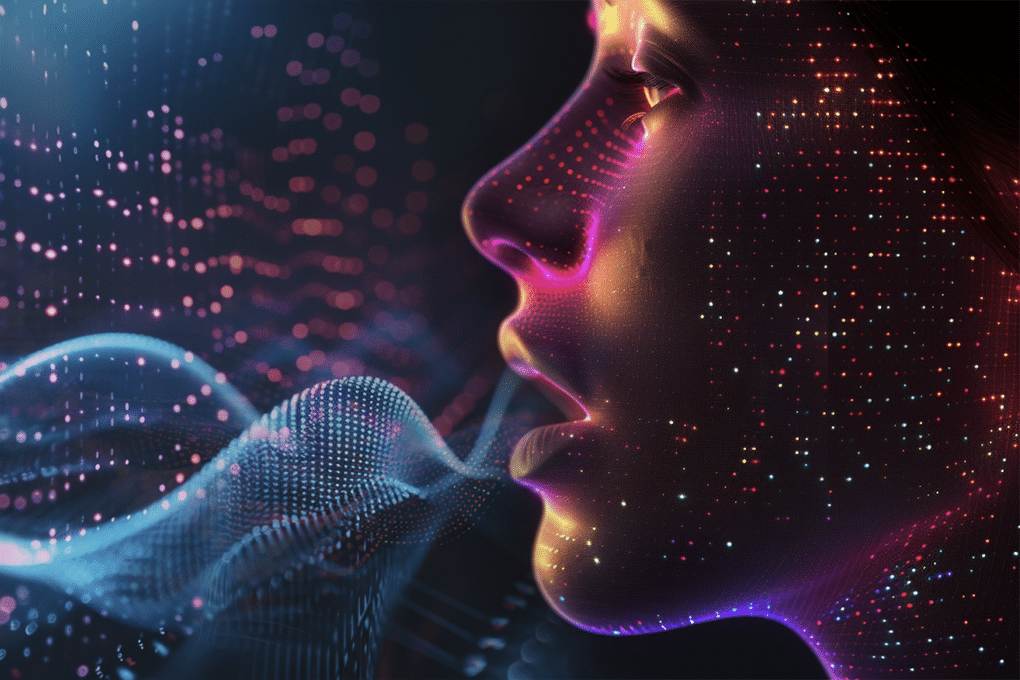

In this assignment, you'll build a sequence-to-sequence model that maps speech utterances to phoneme sequences. You'll implement a recurrent neural network architecture that processes speech feature vectors (MFCCs) and outputs corresponding phoneme sequences.

## Key Components

- **Data Processing**: Work with Mel-Frequency Cepstral Coefficients (MFCCs) and handle variable-length sequences through padding and packing
- **Neural Network Architecture**: Implement a model using CNNs for feature extraction, BiLSTMs for sequential modeling, and optional pyramidal BiLSTMs for downsampling
- **CTC Loss**: Train your model using Connectionist Temporal Classification to handle sequence alignment challenges
- **Decoding Strategies**: Implement both greedy search and beam search for phoneme sequence generation
- **Evaluation**: Use Levenshtein Distance to measure the accuracy of your predicted phoneme sequences

This assignment will give you practical experience with sequence modeling techniques essential to speech recognition systems while exploring various architectural choices and optimization strategies.

# **SET-UP**


Click [**HERE**](https://www.kaggle.com/t/03247d4364694c0286dbe6b70caf0846) to join the competition first!

## [](http://)[](http://)**Colab Users**

### Step 1: Verify GPU
Check that a GPU is available:

In [4]:
!nvidia-smi

Wed Mar 25 12:39:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             49W /   70W |       3MiB /  15360MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 2: Install Required Packages

In [5]:
!pip install wandb==0.23.1 torchinfo kaggle==1.8.0 --quiet
!pip install python-Levenshtein --quiet

### Step 3: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below

In [6]:
from google.colab import userdata

In [7]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "Lydiabebe" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN') # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3387           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection  

### Step 4: Download Dataset

In [8]:
api.competition_download_files('11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026')
!unzip -qo /content/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip -d /content/dataset
!rm -rf /content/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip

In [9]:
!du -h --max-depth=2 /content/dataset/11785-hw3p2

213M	/content/dataset/11785-hw3p2/test-clean/mfcc
213M	/content/dataset/11785-hw3p2/test-clean
3.9G	/content/dataset/11785-hw3p2/train-clean-100/mfcc
115M	/content/dataset/11785-hw3p2/train-clean-100/transcript
4.0G	/content/dataset/11785-hw3p2/train-clean-100
212M	/content/dataset/11785-hw3p2/dev-clean/mfcc
12M	/content/dataset/11785-hw3p2/dev-clean/transcript
223M	/content/dataset/11785-hw3p2/dev-clean
4.4G	/content/dataset/11785-hw3p2


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


QA

In [11]:
import numpy as np
import os

# List a few files in the mfcc directory
mfcc_dir = '/content/dataset/11785-hw3p2/train-clean-100/mfcc'
files = os.listdir(mfcc_dir)
print(files[:3])  # see what files look like

# Load one file and check shape
sample = np.load(os.path.join(mfcc_dir, files[0]))
print("Shape:", sample.shape)
print("Number of MFCCs:", sample.shape[-1])


['8629-261140-0014.npy', '8770-295465-0023.npy', '60-121082-0050.npy']
Shape: (1278, 28)
Number of MFCCs: 28


In [12]:

mfcc_dir = '/content/dataset/11785-hw3p2/train-clean-100/mfcc'
files = os.listdir(mfcc_dir)
print("Number of files:", len(files))

Number of files: 28539


## **Kaggle Users**

### Step 1: Environment Setup

In [ ]:
# !pip install wandb==0.23.1 torchinfo kaggle==1.8.0 --quiet
# !pip install python-Levenshtein --quiet

### Step 2: Get Data

If you are using Kaggle, follow these steps to add the dataset directly to your notebook:
1. Join the kaggle competition
2. Open your **Kaggle Notebook**.  
3. Navigate to **Notebook → Input**.  
4. Click **Add Input**.  
5. Choose "Competition Datasets" and "Your work", and then you'll be able to see the competiation "11785 HW3P2 Utterance to Phoneme Mapping S2026"
6. Click the **➕ (plus sign)** to add the dataset to your notebook.  

### Step 3: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [ ]:
# import os
# import pprint
# os.environ['KAGGLE_USERNAME'] = "<your-username>" # TODO: Verify in Settings
# os.environ['KAGGLE_API_TOKEN'] = "<your-key>" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# # Verify
# import kaggle
# api = kaggle.api  # Already authenticated on import
# api.competitions_list_cli()

## **PSC Users**

### 1️⃣ **Step 1 Setting Up Your Environment on Bridges2**

❗️⚠️ For this homework, we are **providing a shared Conda environment** for the entire class. Therefore, PSC users **do not need to manually install any packages**.

❗️⚠️ For this homework, you need to **download the dataset to the node `$LOCAL`** to avoid I/O bottlenecks from the shared filesystem. This means that each time you run on a new node, you need to download the dataset again. However, as long as you stay on the same node, you do not need to re-download the dataset. Please refer to **Step 3** for the detailed procedure.

Follow these steps to set up the environment and start a Jupyter notebook on Bridges2:

- To run your notebook more efficiently on PSC, we need to use a **Jupyter Server** hosted on a compute node.

- You can use your prefered way of connecting to the Jupyter Server.  **The recommended way is to connect in VSCode.**
Follow the instructions below.

**The recommended way of connecting is:**

#### **Connect in VSCode**
SSH into Bridges2 and navigate to your **Jet directory** (`Jet/home/<your_psc_username>`). Upload your notebook there, and then connect to the Jupyter Server from that directory.

#### **1. SSH into Bridges2**
1）Open VS Code and click on the `Extensions` icon in the left sidebar. Make sure the "**Remote - SSH**" extension is installed.

2）Open the command palette (**Shift+Command+P** on Mac, **Ctrl+Shift+P** on Windows). A search box will appear at the top center. Choose `"Remote-SSH: Add New SSH Host"`, then enter:

```bash
ssh <your_username>@bridges2.psc.edu #change <your_username> to your username
```

Next, choose `"/Users/<your_username>/.ssh/config"` as the config file. A dialog will appear in the bottom right saying "Host Added". Click `"Connect"`, and then enter your password.

(Note: After adding the host once, you can later use `"Remote-SSH: Connect to Host"` and select "bridges2.psc.edu" from the list.)

3）Once connected, click `"Explorer"` in the left sidebar > "Open Folder", and navigate to your home directory under the project grant:
```bash
/jet/home/<your_username>  #change <your_username> to your username
```

4）You can now drag your notebook files directly into the right-hand pane (your remote home directory), or upload them using `scp` into your folder.

> ❗️⚠️ The following steps should be executed in the **VSCode integrated terminal**.

#### **2. Navigate to Your Directory**
Make sure to use this `/jet/home/<your_username>` as your working directory, since all subsequent operations (up to submission) are based on this path.
```bash
cd /jet/home/<your_username>  #change <your_username> to your username
```

#### **3. Request a Compute Node**
```bash
interact -p GPU-shared --gres=gpu:v100-32:1 -t 8:00:00 -A cis240101p
```

#### **4. Load the Anaconda Module**
```bash
module load anaconda3
```

#### **5. Activate the provided HW3 Environment**
```bash
conda deactivate # First, deactivate any existing Conda environment
conda activate /ocean/projects/cis240101p/mzhang23/TA/envs/IDLS26 && export PYTHONNOUSERSITE=1
```

#### **6. Start Jupyter Notebook**
Launch Jupyter Notebook:
```bash
jupyter notebook --no-browser --ip=0.0.0.0
```

Go to **Kernel** → **Select Another Kernel** → **Existing Jupyter Server**
   Enter the URL of the Jupyter Server:```http://{hostname}:{port}/tree?token={token}```
   
   *(Usually, this URL appears in the terminal output after you run `jupyter notebook --no-browser --ip=0.0.0.0`, in a line like:  “Jupyter Server is running at: http://...”)*

   - eg: `http://v011.ib.bridges2.psc.edu:8888/tree?token=e4b302434e68990f28bc2b4ae8d216eb87eecb7090526249`

> **Note**: Replace `{hostname}`, `{port}` and `{token}` with your actual values from the Jupyter output.

#### **7. Import dependencies**

After launching the Jupyter notebook, you can run the cells directly inside the notebook — no need to use the terminal for the remaining steps.

First, import the dependencies.  
(*If you followed the previous steps and correctly activated our shared `hw3p2` environment, you do **not** need to install anything manually.*)

In [ ]:
#Make sure you are in your directory
!pwd #should be /jet/home/<your_username>, if not, uncomment the following line and replace with your actual username:
# %cd /jet/home/<your_username>  #TODO: replace the "<your_username>" to yours

### Step 2: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [ ]:
# import os
# import pprint
# os.environ['KAGGLE_USERNAME'] = "<your-username>" # TODO: Verify in Settings
# os.environ['KAGGLE_API_TOKEN'] = "<your-key>" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# # Verify
# import kaggle
# api = kaggle.api  # Already authenticated on import
# api.competitions_list_cli()

### Step 3: Get Data

❗️⚠️ In this homework, you need to download the dataset to the **GPU node’s local storage (`$LOCAL`)** instead of using the shared /ocean directory, in order to avoid I/O bottlenecks. Using the shared filesystem may slow down training drastically and can take hours per epoch.

Note that **the local storage on a compute node is temporary and will be cleared** when your node time limit is reached or when you move to a different node. Therefore, **every time you run on a new node, you need to re-run the dataset download step**. However, as long as you stay on the same node, you do NOT need to download the dataset again.

In [ ]:
# api.competition_download_files('11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026', path=os.environ["LOCAL"])
# !mkdir -p $LOCAL/dataset
# !unzip -qo $LOCAL/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip -d $LOCAL/dataset
# !rm -f $LOCAL/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip

In [ ]:
# import os
# data_path = "/local/dataset/11785-hw3p2" # this is the path of the dataset on your node
# print("Files in shared hw3p2 dataset:", os.listdir(data_path))

In [ ]:
# !apt-get install tree
# !tree -L 2 /local/dataset/11785-hw3p2

# Imports
(*For PSC users, if you followed the previous steps and correctly activated our shared HW environment, you do **not** need to install anything manually.*)

In [2]:
import torch
import random
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import wandb
import torchaudio.transforms as tat
from torchaudio.models.decoder import cuda_ctc_decoder
import Levenshtein

from sklearn.metrics import accuracy_score
import gc

import glob

import zipfile
from tqdm.auto import tqdm
import os
import datetime


import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


# Config

In [13]:
%%writefile config.yaml

# Subset of dataset to use (1.0 == 100% of data) = when you want to test if your notebook is running, you can use a subset of data
subset: 1.0
learning_rate: 0.001
epochs: 100
train_beam_width: 10 #was 3
test_beam_width: 20 #was 10
mfcc_features: 28 # DO NOT MODIFY

# Set embedding size (the dimensionality of the LSTM hidden state)
embed_size: 256   # {64,128,256} Try out higher embed_size if you have powerfull GPU(RAM) other than T4

batch_size: 128 # Increase if your device can handle it

encoder dropout: 0.2
lstm dropout: 0.2
decoder dropout: 0.2
wandb: True # Set to True if you want to use WanDB

Name: "Lydia_Abebe" # Write your name here

Overwriting config.yaml


In [14]:
import yaml
with open("config.yaml") as file:
    config = yaml.safe_load(file)

In [15]:
config

{'subset': 1.0,
 'learning_rate': 0.001,
 'epochs': 100,
 'train_beam_width': 10,
 'test_beam_width': 20,
 'mfcc_features': 28,
 'embed_size': 256,
 'batch_size': 128,
 'encoder dropout': 0.2,
 'lstm dropout': 0.2,
 'decoder dropout': 0.2,
 'wandb': True,
 'Name': 'Lydia_Abebe'}

### ⚠️ `Note`

- You will need to set the root path to your `11785-hw3p2` folder in `data: root:`. This will depend on your setup. For eg. if you are following out setup instruction:
  - `Colab:`: `"/content/dataset/11785-hw3p2"`
  - `Kaggle:`: `"/kaggle/input/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026/11785-hw3p2"`
  - `PSC`: `"/local/dataset/11785-hw3p2"`

Kindly modify your configurations to suit your ablations.

In [16]:
BATCH_SIZE = config["batch_size"] # Define batch size from config
root = "/content/dataset/11785-hw3p2" # TODO: Specify the directory to your root based on your environment

# Setup Vocabulary (DO NOT MODIFY)

In [17]:
# ARPABET PHONEME MAPPING
# DO NOT CHANGE

CMUdict_ARPAbet = {
    "" : " ",
    "[SIL]": "-", "NG": "G", "F" : "f", "M" : "m", "AE": "@",
    "R"    : "r", "UW": "u", "N" : "n", "IY": "i", "AW": "W",
    "V"    : "v", "UH": "U", "OW": "o", "AA": "a", "ER": "R",
    "HH"   : "h", "Z" :
     "z", "K" : "k", "CH": "C", "W" : "w",
    "EY"   : "e", "ZH": "Z", "T" : "t", "EH": "E", "Y" : "y",
    "AH"   : "A", "B" : "b", "P" : "p", "TH": "T", "DH": "D",
    "AO"   : "c", "G" : "g", "L" : "l", "JH": "j", "OY": "O",
    "SH"   : "S", "D" : "d", "AY": "Y", "S" : "s", "IH": "I",
    "[SOS]": "[SOS]", "[EOS]": "[EOS]"
}


CMUdict = list(CMUdict_ARPAbet.keys())
ARPAbet = list(CMUdict_ARPAbet.values())

PHONEMES = CMUdict[:-2] #To be used for mapping original transcripts to integer indices
LABELS = ARPAbet[:-2] #To be used for mapping predictions to strings

OUT_SIZE = len(PHONEMES) # Number of output classes
print("Number of Phonemes:", OUT_SIZE)

# Indexes of BLANK and SIL phonemes
BLANK_IDX=CMUdict.index('')
SIL_IDX=CMUdict.index('[SIL]')

print("Index of Blank:", BLANK_IDX)
print("Index of [SIL]:", SIL_IDX)

Number of Phonemes: 41
Index of Blank: 0
Index of [SIL]: 1


QA

In [18]:
# First, print the phoneme list to see the mapping
print(CMUdict_ARPAbet)
print(len(CMUdict_ARPAbet))

# Map the phonemes to their indices
phonemes = ['B', 'IH', 'K', 'SH', 'AA']
result = [CMUdict_ARPAbet[p] for p in phonemes]
print(result)

{'': ' ', '[SIL]': '-', 'NG': 'G', 'F': 'f', 'M': 'm', 'AE': '@', 'R': 'r', 'UW': 'u', 'N': 'n', 'IY': 'i', 'AW': 'W', 'V': 'v', 'UH': 'U', 'OW': 'o', 'AA': 'a', 'ER': 'R', 'HH': 'h', 'Z': 'z', 'K': 'k', 'CH': 'C', 'W': 'w', 'EY': 'e', 'ZH': 'Z', 'T': 't', 'EH': 'E', 'Y': 'y', 'AH': 'A', 'B': 'b', 'P': 'p', 'TH': 'T', 'DH': 'D', 'AO': 'c', 'G': 'g', 'L': 'l', 'JH': 'j', 'OY': 'O', 'SH': 'S', 'D': 'd', 'AY': 'Y', 'S': 's', 'IH': 'I', '[SOS]': '[SOS]', '[EOS]': '[EOS]'}
43
['b', 'I', 'k', 'S', 'a']


### Sample data inspection & sanity check

In [19]:
test_mfcc = f"{root}/train-clean-100/mfcc/103-1240-0000.npy"
test_transcript = f"{root}/train-clean-100/transcript/103-1240-0000.npy"

mfcc = np.load(test_mfcc)
transcript = np.load(test_transcript)[1:-1] #Removed [SOS] and [EOS]

print("MFCC Shape:", mfcc.shape)
print("\nMFCC:\n", mfcc)
print("\nTranscript shape:", transcript.shape)

print("\nOriginal Transcript:\n", transcript)

# map the loaded transcript (from phonemes representation) to corresponding labels representation
mapped_transcript = [CMUdict_ARPAbet[k] for k in transcript]
print("\nTranscript mapped from PHONEMES representation to LABELS representation:\n", mapped_transcript)

# Mapping list of PHONEMES to list of Integer indexes
map = {k: i for i, k in enumerate(PHONEMES)}
print("\nMapping list of PHONEMES to list of Integer indexes:\n", map)



MFCC Shape: (1404, 28)

MFCC:
 [[ 1.10582151e+01  1.28330450e+01  2.10689220e+01 ... -8.75406042e-02
   7.30623007e-02  9.48924713e+01]
 [ 1.16850815e+01  1.38329487e+01  2.19087906e+01 ... -1.39180899e-01
  -6.15991093e-02  9.55670319e+01]
 [ 1.11048431e+01  1.67276516e+01  2.28863831e+01 ... -4.03698802e-01
   8.09250996e-02  9.54314651e+01]
 ...
 [ 2.62413955e+00 -1.26996317e+01  2.79472313e+01 ... -1.49060452e+00
  -2.67574161e-01  1.16191261e+02]
 [ 3.05713993e-02 -1.20763254e+01  2.60116520e+01 ... -8.54688883e-01
  -1.20284989e-01  1.17127373e+02]
 [-1.33604801e+00 -1.17101593e+01  2.44703121e+01 ... -9.30283189e-01
  -8.16672146e-02  1.18280014e+02]]

Transcript shape: (145,)

Original Transcript:
 ['[SIL]' 'CH' 'AE' 'P' 'T' 'ER' 'W' 'AH' 'N' '[SIL]' 'M' 'IH' 'S' 'IH' 'Z'
 'R' 'EY' 'CH' 'AH' 'L' 'IH' 'N' 'D' 'IH' 'Z' 'S' 'ER' 'P' 'R' 'AY' 'Z'
 'D' '[SIL]' 'M' 'IH' 'S' 'IH' 'Z' 'R' 'EY' 'CH' 'AH' 'L' 'IH' 'N' 'D'
 '[SIL]' 'L' 'AY' 'V' 'D' '[SIL]' 'JH' 'AH' 'S' 'T' 'W' 'EH' 'R' '

# Dataset and Dataloader

### Train Data

In [23]:
#edited from recs

In [20]:
class AudioDataset(torch.utils.data.Dataset):

    # For this homework, we give you full flexibility to design your data set class.
    # Hint: The data from HW1 is very similar to this HW

    #TODO
    def __init__(self, root, subset, augment=False):
        '''
        Initializes the dataset.

        INPUTS: What inputs do you need here?
        '''

        self.PHONEMES = PHONEMES
        self.subset = config['subset']

        # TODO
        # Define the directories containing MFCC and transcript files
        # self.mfcc_dir = ___ #TODO
        # self.transcript_dir = ___ #TODO
        # self.mfcc_dir       = os.path.join(root, partition, 'mfcc')
        # self.transcript_dir = os.path.join(root, partition, 'transcript')

        # Changed To this:
        self.mfcc_dir       = os.path.join(root, subset, 'mfcc')
        self.transcript_dir = os.path.join(root, subset, 'transcript')

        # List all files in the directories. Remember to sort the files
        self.mfcc_files       = sorted(glob.glob(os.path.join(self.mfcc_dir, '*.npy')))
        self.transcript_files = sorted(glob.glob(os.path.join(self.transcript_dir, '*.npy')))



        # Compute size of data subset
        subset_size = int(self.subset * len(self.mfcc_files))

        # Select subset of data to use
        self.mfcc_files = self.mfcc_files[:subset_size]
        self.transcript_files = self.transcript_files[:subset_size]

        assert(len(self.mfcc_files) == len(self.transcript_files))

        #TODO
        # WHAT SHOULD THE LENGTH OF THE DATASET BE?
        self.length = len(self.mfcc_files) #TODO
        # phoneme → integer index mapping
        self.p2i = {p: i for i, p in enumerate(PHONEMES)}

        #TODO
        # CREATE AN ARRAY TO STORE ALL PROCESSED MFCCS AND TRANSCRIPTS
        # LOAD ALL MFCCS AND CORRESPONDING TRANSCRIPTS AND DO THE NECESSARY PRE-PROCESSING
          # HINTS:
          # WHAT NORMALIZATION TECHNIQUE DID YOU USE IN HW1? CAN WE USE IT HERE?
          # REMEMBER TO REMOVE [SOS] AND [EOS] FROM TRANSCRIPTS
        '''
        You may decide to do this in __getitem__ if you wish.
        However, doing this here will make the __init__ function take the load of
        loading the data, and shift it away from training.
        '''
        #TODO
        # HOW CAN WE REPRESENT PHONEMES? CAN WE CREATE A MAPPING FOR THEM?
        # HINT: TENSORS CANNOT STORE NON-NUMERICAL VALUES OR STRINGS

        # load all MFCCs and transcripts into memory
        self.mfccs = []
        self.transcripts = []
        for mf, tf in zip(self.mfcc_files, self.transcript_files):
            mfcc = np.load(mf)
            mfcc = (mfcc - mfcc.mean(axis=0)) / (mfcc.std(axis=0) + 1e-8)
            self.mfccs.append(torch.FloatTensor(mfcc))

            transcript = np.load(tf)[1:-1]  # remove [SOS] and [EOS]
            self.transcripts.append(torch.LongTensor([self.p2i[p] for p in transcript]))

        self.augment = augment



    def __len__(self):
      #TODO: What do we return here?
        return self.length #TODO


    def __getitem__(self, ind):

        '''
        TODO: RETURN THE MFCC COEFFICIENTS AND ITS CORRESPONDING LABELS
        If you didn't do the loading and processing of the data in __init__,
        do that here.
        Once done, return a tuple of features and labels.
        '''

        #mfcc = ___ #TODO
        #transcript = ___ #TODO
        mfcc = self.mfccs[ind]
        transcript = self.transcripts[ind]

        # NOTE: Remember to convert mfcc and transcripts to tensors here, if not done already in __init__
        return mfcc, transcript



    def collate_fn(self,batch):
        '''
        TODO:
        1.  Extract the features and labels from 'batch'
        2.  We will additionally need to pad both features and labels,
            look at pytorch's docs for pad_sequence
        3.  This is a good place to perform transforms, if you so wish.
            Performing them on batches will speed the process up a bit.
        4.  Return batch of features, labels, lenghts of features,
            and lengths of labels.
        '''

        # Extract batch of input MFCCs and batch of output transcripts separately
        batch_mfcc = [item[0] for item in batch] #TODO
        batch_transcript = [item[1] for item in batch] #TODO
        # Store original lengths of the MFCCS and transcripts in the batches
        lengths_mfcc = [mfcc.shape[0] for mfcc in batch_mfcc] #TODO
        lengths_transcript = [transcript.shape[0] for transcript in batch_transcript] #TODO

        # Pad the MFCC sequences and transcripts
        # HINT: CHECK OUT -> pad_sequence (imported above)
        # Also be sure to check the input format (batch_first)
        # Note: (resulting shape of padded MFCCs: [batch, time, freq])
        batch_mfcc_pad = pad_sequence(batch_mfcc, batch_first=True) #TODO

        batch_transcript_pad = pad_sequence(batch_transcript, batch_first=True) #TODO

        # SpecAugment — only on training data
        # Shape expected by masking: (..., freq, time) so permute first
        if self.augment:
          x = batch_mfcc_pad.permute(0, 2, 1)  # (B, F, T)
          freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=10)
          time_mask = torchaudio.transforms.TimeMasking(time_mask_param=40)
          x = freq_mask(x)
          x = time_mask(x)
          batch_mfcc_pad = x.permute(0, 2, 1)  # (B, T, F)



        # TODO: You may apply some transformations, Time and Frequency masking, here in the collate function;
        # Food for thought -> Why are we applying the transformation here and not in the __getitem__?
        #                  -> Would we apply transformation on the validation set as well?
        #                  -> Is the order of axes / dimensions as expected for the transform functions?
        #                     -> Time & Freq. Masking functions both expect input of shape (..., freq, time),
        #                        So permute your input dimensions appropriately before & after using these functions.



        # Return the following values: padded features, padded labels, actual length of features, actual length of the labels
        return batch_mfcc_pad, batch_transcript_pad, torch.tensor(lengths_mfcc), torch.tensor(lengths_transcript)



### Test Data

do

In [21]:
# TODO
# Food for thought -> Do you need to apply transformations in this test dataset class?
class AudioDatasetTest(torch.utils.data.Dataset):

    def __init__(self, root, partition):
        self.mfcc_dir = os.path.join(root, partition, 'mfcc')
        self.mfcc_files = sorted(glob.glob(os.path.join(self.mfcc_dir, '*.npy')))

        self.mfccs = []
        for mf in self.mfcc_files:
            mfcc = np.load(mf)
            mfcc = (mfcc - mfcc.mean(axis=0)) / (mfcc.std(axis=0) + 1e-8)
            self.mfccs.append(torch.FloatTensor(mfcc))

    def __len__(self):
        return len(self.mfccs)

    def __getitem__(self, ind):
        return self.mfccs[ind]
        #originaly given
    def collate_fn(self, batch):
         batch_mfcc = batch
         lengths_mfcc = [mfcc.shape[0] for mfcc in batch_mfcc]
         batch_mfcc_pad = pad_sequence(batch_mfcc, batch_first=True)
         return batch_mfcc_pad, torch.tensor(lengths_mfcc)

### Data loaders

In [22]:
# To free up ram
import gc
gc.collect()

0

In [27]:
#Check if right

In [23]:
# Create objects for the dataset classes
train_data = AudioDataset(root, 'train-clean-100', augment=True) # TODO: Fill in the required parameters
val_data = AudioDataset(root, 'dev-clean', augment=False) # TODO: You can either use the same class for train data with some modifications or make a new one :)
test_data = AudioDatasetTest(root, 'test-clean') # TODO: Fill in the required parameters

In [24]:
# Do NOT forget to pass in the collate function as an argument while creating the dataloader
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=train_data.collate_fn, num_workers=4, pin_memory=True)


val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=val_data.collate_fn, num_workers=2, pin_memory=True) #TODO

test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=test_data.collate_fn, num_workers=2, pin_memory=True) #TODO

print("Batch size: ", config['batch_size'])
print("Train dataset samples = {}, batches = {}".format(train_data.__len__(), len(train_loader)))
print("Val dataset samples = {}, batches = {}".format(val_data.__len__(), len(val_loader)))
print("Test dataset samples = {}, batches = {}".format(test_data.__len__(), len(test_loader)))

Batch size:  128
Train dataset samples = 28539, batches = 223
Val dataset samples = 2703, batches = 22
Test dataset samples = 2620, batches = 21


In [25]:
import torchaudio


In [26]:
# sanity check
for data in train_loader:
    x, y, lx, ly = data
    print(x.shape, y.shape, lx.shape, ly.shape)
    break

torch.Size([128, 1666, 28]) torch.Size([128, 208]) torch.Size([128]) torch.Size([128])


# Visualize Data

Note: In the visualized graph, do not confuse padded regions of the MFCC sequences with time/freq augmentation masks. Remember all MFCCs were padded to the maximum sequence length

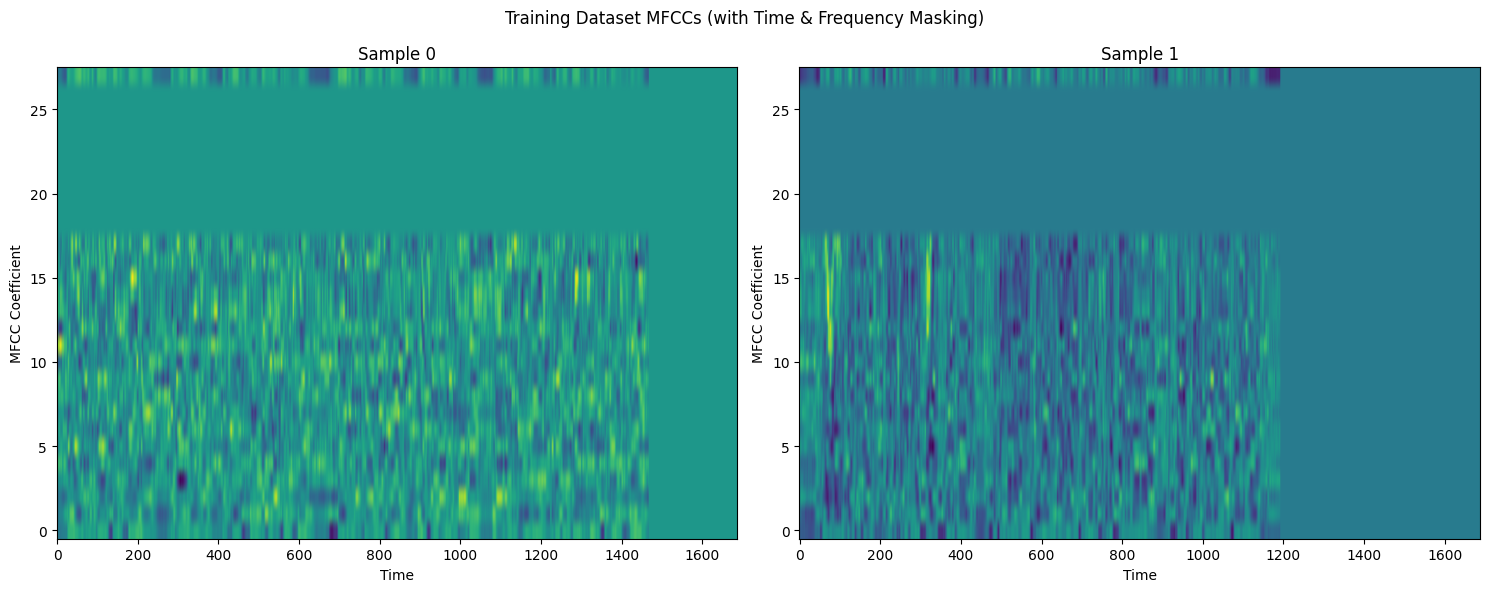

In [27]:
import matplotlib.pyplot as plt

def visualize_batch(loader, title="Dataset Visualization", num_samples=2):
    """
    Visualizes MFCC features from a single batch of data.

    Args:
        loader (DataLoader): DataLoader object (for train, val, or test).
        title (str): Title of the plot.
        num_samples (int): Number of samples to visualize from the batch.
    """
    # Get one batch from the loader.
    batch = next(iter(loader))

    # The collate_fn we defined in the dataset class returns a tuple, where the first element is the padded MFCC tensor.
    mfcc_batch = batch[0] if isinstance(batch, (tuple, list)) else batch

    # Limit to a few samples.
    num_samples = min(num_samples, mfcc_batch.size(0))

    # Create subplots.
    fig, axes = plt.subplots(1, num_samples, figsize=(15,6))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Each MFCC tensor is of shape [time, frequency].
        # Transpose for visualization: time on x-axis, features on y-axis.
        mfcc_img = mfcc_batch[i].cpu().numpy().T
        im = axes[i].imshow(mfcc_img, origin="lower", aspect="auto", cmap="viridis")
        axes[i].set_title(f"Sample {i}")
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("MFCC Coefficient")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Visualize batches of data
visualize_batch(train_loader, title="Training Dataset MFCCs (with Time & Frequency Masking)")

# Network

## Basic network (Optional)

This is a basic block for understanding, you can skip this and move to pBLSTM one

In [28]:
torch.cuda.empty_cache()

class Network(nn.Module):

    def __init__(self):

        super(Network, self).__init__()

        # TODO: Adding some sort of embedding layer or feature extractor might help performance.
        # You can use CNNs as Embedding layer to extract features. Keep in mind the Input dimensions and expected dimension of Pytorch CNN.
        # Food for thought -> What type of Conv layers can be used here?
        #                  -> What should be the size of input channels to the first layer?
        #self.embedding = _________________________ #TODO
        self.embedding = nn.Sequential(
            Permute(),
            nn.Conv1d(config['mfcc_features'], 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            Permute(),
        )

        # TODO : look up the documentation. You might need to pass some additional parameters.
        #self.lstm = nn.LSTM(input_size = __________________, hidden_size = 256, num_layers = 3) #TODO
        self.lstm = nn.LSTM(input_size=128, hidden_size=256, num_layers=3, batch_first=True)


        self.classification = nn.Sequential(nn.Linear(256, OUT_SIZE)
            #TODO: Linear layer with in_features from the lstm module above and out_features = OUT_SIZE
        )


        self.logSoftmax = nn.LogSoftmax(dim=2) #TODO: Apply a log softmax here. Which dimension would apply it on ?

    def forward(self, x, lx):
        #TODO
        # The forward function takes 2 parameter inputs here. Why?
        # Refer to the handout for hints
        x_em = self.embedding(x)
        pack_seq = pack_padded_sequence(x_em, lx, batch_first=True, enforce_sorted=False)
        x, _ = self.lstm(pack_seq)
        x = self.classification(x)
        x = self.logSoftmax(x)
        return x


## Initialize Basic Network
(If trying out the basic Network)

In [29]:
class Permute(nn.Module):
    def forward(self, x):
        return x.permute(0, 2, 1)

In [30]:
torch.cuda.empty_cache()

model = Network().to(device)

# Check to stay below 20 MIL Parameter limit
assert sum(p.numel() for p in model.parameters() if p.requires_grad) < 20_000_000, "Exceeds 20 MIL params. Any submission made to Kaggle with this model will be flagged as an AIV."

print(model)

Network(
  (embedding): Sequential(
    (0): Permute()
    (1): Conv1d(28, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): Permute()
  )
  (lstm): LSTM(128, 256, num_layers=3, batch_first=True)
  (classification): Sequential(
    (0): Linear(in_features=256, out_features=41, bias=True)
  )
  (logSoftmax): LogSoftmax(dim=2)
)



## ASR Network
We define everything we need for the ASR model in separate classes, and put them all together in the end

#### Permute class

In [31]:
class Permute(torch.nn.Module):
    '''
    Used to transpose/permute the dimensions of an MFCC tensor.
    '''
    def forward(self, x):
        return x.transpose(1, 2)

#### Pyramidal Bi-LSTM (pBLSTM) class

In [32]:
class pBLSTM(torch.nn.Module):

    '''
    Pyramidal BiLSTM
    Read the write up/paper and understand the concepts and then write your implementation here.

    At each step,
    1. Pad your input if it is packed (Unpack it)
    2. Reduce the input length dimension by concatenating feature dimension
        (Tip: Write down the shapes and understand)
        (i) How should  you deal with odd/even length input?
        (ii) How should you deal with input length array (x_lens) after truncating the input?
    3. Pack your input
    4. Pass it into LSTM layer

    To make our implementation modular, we pass 1 layer at a time.
    '''

    def __init__(self, input_size, hidden_size):
        super(pBLSTM, self).__init__()
        self.blstm = nn.LSTM(input_size=input_size * 2, hidden_size=hidden_size,
                             num_layers=1, bidirectional=True, batch_first=True)


        #self.blstm = __________________________________ # TODO: Initialize a single layer bidirectional LSTM with the given input_size and hidden_size

    def forward(self, x_packed): # x_packed is a PackedSequence

        # TODO: Pad Packed Sequence
        # TODO: Call self.trunc_reshape() which downsamples the time steps of x and increases the feature dimensions as mentioned above
        # self.trunc_reshape will return 2 outputs. What are they? Think about what quantites are changing.
        # TODO: Pack Padded Sequence. What output(s) would you get?
        # TODO: Pass the sequence through bLSTM
        # What do you return?
        #return ____________________________________#TODO
        x, x_lens = pad_packed_sequence(x_packed, batch_first=True)
        x, x_lens = self.trunc_reshape(x, x_lens)
        x_packed = pack_padded_sequence(x, x_lens.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.blstm(x_packed)
        return out

    def trunc_reshape(self, x, x_lens):
        # TODO: If you have odd number of timesteps, how can you handle it? (Hint: You can exclude them)
        # TODO: Reshape x. When reshaping x, you have to reduce number of timesteps by a downsampling factor while increasing number of features by the same factor
        # TODO: Reduce lengths by the same downsampling factor
        B, T, F = x.shape
        if T % 2 != 0:
            x = x[:, :-1, :]
            T -= 1
        x = x.reshape(B, T // 2, F * 2)
        x_lens = torch.clamp(x_lens // 2, min=1)

        return x, x_lens

#### Util for LSTM


In [33]:
class LSTMWrapper(torch.nn.Module):
    '''
    Used to get only output of lstm, not the hidden states.
    '''
    def __init__(self, lstm):
        super(LSTMWrapper, self).__init__()
        self.lstm = lstm

    def forward(self, x):
        output, _ = self.lstm(x)
        return output

#### Encoder class

In [34]:
class Encoder(torch.nn.Module):
    '''
    The Encoder takes utterances as inputs and returns latent feature representations
    '''
    def __init__(self, input_size, encoder_hidden_size):
        super(Encoder, self).__init__()
        # TODO: You can use CNNs as Embedding layer to extract features. Keep in mind the Input dimensions and expected dimension of Pytorch CNN.
        # Food for thought -> What type of Conv layers can be used here?
        #                  -> What should be the size of input channels to the first layer?
        #self.embedding = #TODO
        self.embedding = nn.Sequential(
            Permute(),
            nn.Conv1d(input_size, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            Permute(),
            nn.Dropout(config['encoder dropout'])
        )

        # TODO:
        self.BLSTMs = LSTMWrapper(
            # TODO: Look up the documentation. You might need to pass some additional parameters.
            torch.nn.LSTM(input_size=128, hidden_size=encoder_hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=config['lstm dropout']) #TODO
          )

        self.pBLSTMs = torch.nn.Sequential( # How many pBLSTMs are required?
            # TODO: Fill this up with pBLSTMs - What should the input_size be?
            # Hint: You are downsampling timesteps by a factor of 2, upsampling features by a factor of 2 and the LSTM is bidirectional)
            # Optional: Dropout/Locked Dropout after each pBLSTM (Not needed for early submission)
            # https://github.com/salesforce/awd-lstm-lm/blob/dfd3cb0235d2caf2847a4d53e1cbd495b781b5d2/locked_dropout.py#L5
            # ...
            # ...
            pBLSTM(input_size=2 * encoder_hidden_size, hidden_size=encoder_hidden_size),
            pBLSTM(input_size=2 * encoder_hidden_size, hidden_size=encoder_hidden_size),
            pBLSTM(input_size=2 * encoder_hidden_size, hidden_size=encoder_hidden_size), #new bc adding a 3rd pBLSTM Layer will add More Capacity

        )

    def forward(self, x, x_lens):
        # Where are x and x_lens coming from? The dataloader

        # TODO: Call the embedding layer
        x = self.embedding(x)
        # TODO: Pack Padded Sequence
        x = pack_padded_sequence(x, x_lens.cpu(), batch_first=True, enforce_sorted=False)
        # TODO: Pass Sequence through the Bi-LSTM layer
        x = self.BLSTMs(x)
        # TODO: Pass Sequence through the pyramidal Bi-LSTM layer
        x = self.pBLSTMs(x)
        # TODO: Pad Packed Sequence
        encoder_outputs, encoder_lens = pad_packed_sequence(x, batch_first=True)
        # Remember the number of output(s) each function returns
        return encoder_outputs, encoder_lens

#### Decoder class

In [35]:
class Decoder(torch.nn.Module):

    def __init__(self, embed_size, output_size= 41):
        super().__init__()

        self.mlp = torch.nn.Sequential(

            Permute(),
            torch.nn.BatchNorm1d(2 * embed_size),
            Permute(),
            torch.nn.Linear(2 * embed_size, 512),
            torch.nn.GELU(),
            torch.nn.Dropout(config['decoder dropout']),
            Permute(),
            torch.nn.BatchNorm1d(512),
            Permute(),
            torch.nn.Linear(512, output_size),

            #TODO define your MLP arch. Refer HW1P2
            #Use Permute Block before and after BatchNorm1d() to match the size
            #Now you can stack your MLP layers
        )
        self.softmax = torch.nn.LogSoftmax(dim=2)


    def forward(self, encoder_out):

        #TODO: Call your MLP
        out = self.mlp(encoder_out)
        out = self.softmax(out)
        #TODO: Think about what should be the final output of the decoder for classification
        return out

#### ASR Model Class

In [36]:
class ASRModel(torch.nn.Module):

    def __init__(self, input_size, embed_size= 192, output_size= len(PHONEMES)):
        super().__init__()

        # Initialize encoder and decoder
        self.encoder = Encoder(input_size, embed_size)
        self.decoder = Decoder(embed_size, output_size)


    def forward(self, x, lengths_x):

        encoder_out, encoder_lens   = self.encoder(x, lengths_x)
        decoder_out                 = self.decoder(encoder_out)

        return decoder_out, encoder_lens

## Initialize ASR Network

In [37]:
model = ASRModel(
    input_size  = config['mfcc_features'],  #TODO,
    embed_size  = config['embed_size'], #TODO
    output_size = len(PHONEMES)
).to(device)

# Check to stay below 20 MIL Parameter limit
assert sum(p.numel() for p in model.parameters() if p.requires_grad) < 20_000_000, "Exceeds 20 MIL params. Any submission made to Kaggle with this model will be flagged as an AIV."

In [48]:
summary(model, input_data=[x.to(device), lx.to(device)])

Layer (type:depth-idx)                   Output Shape              Param #
ASRModel                                 [128, 207, 41]            --
├─Encoder: 1-1                           [128, 207, 512]           --
│    └─Sequential: 2-1                   [128, 1660, 128]          --
│    │    └─Permute: 3-1                 [128, 28, 1660]           --
│    │    └─Conv1d: 3-2                  [128, 128, 1660]          10,880
│    │    └─ReLU: 3-3                    [128, 128, 1660]          --
│    │    └─Conv1d: 3-4                  [128, 128, 1660]          49,280
│    │    └─ReLU: 3-5                    [128, 128, 1660]          --
│    │    └─Permute: 3-6                 [128, 1660, 128]          --
│    │    └─Dropout: 3-7                 [128, 1660, 128]          --
│    └─LSTMWrapper: 2-2                  [158351, 512]             --
│    │    └─LSTM: 3-8                    [158351, 512]             2,367,488
│    └─Sequential: 2-3                   [19734, 512]              --


# Training Config
Initialize Loss Criterion, Optimizer, CTC Beam Decoder, Scheduler, Scaler (Mixed-Precision), etc

In [38]:
# TODO: Define CTC loss as the criterion. How would the losses be reduced?
criterion = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)
# CTC Loss: https://pytorch.org/docs/stable/generated/torch.nn.CTCLoss.html
# Refer to the handout for hints

optimizer =  torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=1e-5) #TODO: What goes in here?

# TODO: Declare the decoder. Use the PyTorch Cuda CTC Decoder to decode phonemes
# CTC Decoder: https://pytorch.org/audio/2.1/generated/torchaudio.models.decoder.cuda_ctc_decoder.html
decoder = cuda_ctc_decoder(tokens=LABELS, nbest=1, beam_size=config['train_beam_width']) #TODO

# TODO:
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) #old
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'], eta_min=1e-6) #new

# Mixed Precision, if you need it
scaler = torch.cuda.amp.GradScaler()

### Levenshtein

In [39]:
def decode_prediction(output, output_lens, decoder, PHONEME_MAP = LABELS):

    # Look at docs for CUDA_CTC_DECODER for more info on how it was used here:
    # https://pytorch.org/audio/main/tutorials/asr_inference_with_cuda_ctc_decoder_tutorial.html
    output = output.contiguous()
    output_lens = output_lens.to(torch.int32).contiguous()
    beam_results = decoder(output, output_lens.to(torch.int32)) #lengths - list of lengths

    pred_strings                    = []

    for i in range(len(beam_results)):
        # Create the prediction from the output of the cuda_ctc_decoder. Don't forget to map it using PHONEMES_MAP.
        # NOTE: PHONEMES_MAP should be the phoneme LABELS instead, as defined above as LABELS
        # Get the top prediction for each sequence in the batch
        top_beam_results = beam_results[i][0].tokens
        pred_strings.append(''.join([PHONEME_MAP[t] for t in top_beam_results]))

        # TODO: Map the sequence of indices to actual phoneme LABELS and join them into a string
        # Append to predited strings list after joining

    return pred_strings

def calculate_levenshtein(output, label, output_lens, label_lens, decoder, PHONEME_MAP= LABELS): # y - sequence of integers

    dist            = 0
    batch_size      = label.shape[0]

    pred_strings    = decode_prediction(output, output_lens, decoder, PHONEME_MAP)

    for i in range(batch_size):
        # TODO: Get predicted string and label string for each element in the batch

        label_string = ''.join([PHONEME_MAP[label[i][j].item()] for j in range(label_lens[i])])
        pred_string = pred_strings[i] # TODO: Predicted string from decode_prediction
        dist += Levenshtein.distance(pred_string, label_string)

    # Average the distance over the batch
    dist /= batch_size # Think about why we are doing this
    return dist

In [40]:
torch.cuda.empty_cache()
gc.collect()

30

## Test Implementation

In [41]:
# test code to check shapes

model.eval()
for i, data in enumerate(val_loader, 0):
    x, y, lx, ly = data
    x, y = x.to(device), y.to(device)
    lx, ly = lx.to(device), ly.to(device)
    h, lh = model(x, lx)
    print(h.shape)
    h = torch.permute(h, (1, 0, 2))
    print(h.shape, y.shape)
    loss = criterion(h, y, lh, ly)
    print(loss)

    print(calculate_levenshtein(torch.permute(h, (1, 0, 2)), y, lh.to(device), ly, decoder, LABELS))

    del x, y, lx, ly, h, lh, loss
    torch.cuda.empty_cache()

    break

torch.Size([128, 367, 41])
torch.Size([367, 128, 41]) torch.Size([128, 265])
tensor(3.9135, device='cuda:0', grad_fn=<MeanBackward0>)
58.3125


## WandB

In [42]:
# Use wandb? Resume Training?
USE_WANDB = config['wandb']

RESUME_LOGGING = False # Set this to true if you are resuming training from a previous run

# Create your wandb run

run_name = '{}_early_submission'.format(config['Name'])

# If you are resuming an old run
if USE_WANDB:

    wandb.login(key= userdata.get('wandb_key')) #used colab secrets manager

    if RESUME_LOGGING:
        run = wandb.init(
            id     = "March_20", ### Insert specific run id here if you want to resume a previous run
            resume = "must", ### You need this to resume previous runs
            project = "hw3p2-ablations", ### Project should be created in your wandb
            settings = wandb.Settings(_service_wait=300)
        )


    else:
        run = wandb.init(
            name    = run_name, ### Wandb creates random run names if you skip this field, we recommend you give useful names
            reinit  = True, ### Allows reinitalizing runs when you re-run this cell
            project = "hw3p2-ablations", ### Project should be created in your wandb account
            config  = config ### Wandb Config for your run
        )

        ### Save your model architecture as a string with str(model)
        model_arch  = str(model)
        ### Save it in a txt file
        arch_file   = open("model_arch.txt", "w")
        file_write  = arch_file.write(model_arch)
        arch_file.close()

        ### log it in your wandb run with wandb.save()
        wandb.save('model_arch.txt')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: labebe (PerforatedAI_IDL) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


# Training Functions

In [43]:
# Train function
def train_model(model, train_loader, criterion, optimizer):

    model.train()
    batch_bar = tqdm(total=len(train_loader), dynamic_ncols=True, leave=False, position=0, desc='Train')

    total_loss = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()

        x, y, lx, ly = data
        x, y = x.to(device), y.to(device)
        lx, ly = lx.to(device), ly.to(device)

        with torch.cuda.amp.autocast():
            h, lh = model(x, lx)
            h = torch.permute(h, (1, 0, 2))
            loss = criterion(h, y, lh, ly)

        total_loss += loss.item()

        batch_bar.set_postfix(
            loss="{:.04f}".format(float(total_loss / (i + 1))),
            lr="{:.06f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update() # Update tqdm bar

        scaler.scale(loss).backward() # This is a replacement for loss.backward()

        scaler.unscale_(optimizer) #new
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) #new


        scaler.step(optimizer) # This is a replacement for optimizer.step()
        scaler.update() # This is something added just for FP16

        del x, y, lx, ly, h, lh, loss
        torch.cuda.empty_cache()

    batch_bar.close() # You need this to close the tqdm bar

    return total_loss / len(train_loader)


# Eval function
def validate_model(model, val_loader, decoder, phoneme_map= LABELS):

    model.eval()
    batch_bar = tqdm(total=len(val_loader), dynamic_ncols=True, position=0, leave=False, desc='Val')

    total_loss = 0
    vdist = 0

    for i, data in enumerate(val_loader):

        x, y, lx, ly = data
        x, y = x.to(device), y.to(device)
        lx, ly = lx.to(device), ly.to(device)

        with torch.inference_mode():
            h, lh = model(x, lx)
            h = torch.permute(h, (1, 0, 2))
            loss = criterion(h, y, lh, ly)

        total_loss += loss.item()
        vdist += calculate_levenshtein(torch.permute(h, (1, 0, 2)), y, lh.to(device), ly, decoder, phoneme_map)

        batch_bar.set_postfix(loss="{:.04f}".format(float(total_loss / (i + 1))), dist="{:.04f}".format(float(vdist / (i + 1))))

        batch_bar.update()

        del x, y, lx, ly, h, lh, loss
        torch.cuda.empty_cache()

    batch_bar.close()
    total_loss = total_loss/len(val_loader)
    val_dist = vdist/len(val_loader)
    return total_loss, val_dist


### Model Saving & Loading functions

In [44]:
def save_model(model, optimizer, scheduler, metric, epoch, path):
    torch.save(
        {'model_state_dict'         : model.state_dict(),
         'optimizer_state_dict'     : optimizer.state_dict(),
         'scheduler_state_dict'     : scheduler.state_dict() if scheduler is not None else {},
         metric[0]                  : metric[1],
         'epoch'                    : epoch},
         path
    )

def load_model(path, model, optimizer= None, scheduler= None, metric='valid_dist'):

    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer != None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler != None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch   = checkpoint['epoch']
    metric  = checkpoint[metric]

    print("\nResuming training from epoch:", epoch)
    print('----------------------------------------\n')
    print("Epochs left: ", config['epochs'] - epoch)
    print("Optimizer: \n", optimizer)
    print("Current Schedueler T_cur:", scheduler.T_cur)

    print("Best Val Dist:", metric)

    return [model, optimizer, scheduler, epoch, metric]

## Training Loop

In [45]:
# Instantiate variables used in training loop
last_epoch_completed = 0
best_lev_dist = float("inf")

#### Uncomment this if resuming training from model checkpoint

In [57]:
# RESUME_TRAINING = True # Set this to true if you are resuming training from a model checkpoint

# if RESUME_TRAINING:

#     checkpoint_path = ''
#     checkpoint = load_model(checkpoint_path, model, optimizer, scheduler, metric='valid_dist')

#     last_epoch_completed = checkpoint[3]
#     best_lev_dist = checkpoint[4]

In [58]:
# Set up checkpoint directories and WanDB logging watch
checkpoint_root = os.path.join(os.getcwd(), 'checkpoints')
os.makedirs(checkpoint_root, exist_ok=True)
wandb.watch(model, log="all")

checkpoint_best_model_filename = 'checkpoint-best-model.pth'
checkpoint_last_epoch_filename = 'checkpoint-last-epoch.pth'
epoch_model_path = os.path.join(checkpoint_root, checkpoint_last_epoch_filename)
best_model_path = os.path.join(checkpoint_root, checkpoint_best_model_filename)

# WanDB log watch
if config['wandb']:
  wandb.watch(model, log="all")


In [46]:
# Clear RAM for storage before you start training
torch.cuda.empty_cache()
gc.collect()

585

#### Iterate over the number of epochs to train and evaluate your model


In [47]:
from IPython.display import clear_output


In [49]:
#TODO: Please complete the training loop
lev_history = [] #new
for epoch in range(last_epoch_completed, config['epochs']):

    print("\nEpoch: {}/{}".format(epoch + 1, config['epochs']))

    curr_lr = float(optimizer.param_groups[0]['lr']) #TODO

    train_loss = train_model(model, train_loader, criterion, optimizer) #TODO
    valid_loss, valid_dist = validate_model(model, val_loader, decoder) #TODO

    lev_history.append(valid_dist)
    #this code will display a new chart after each single epoch,
    #showing the history up to that point
    clear_output(wait=True)

    plt.figure(figsize=(10, 4))
    plt.plot(lev_history, marker='o', label='Val Levenshtein Distance')
    plt.axhline(y=3, color='r', linestyle='--', label='Target (< 3)')
    plt.xlabel('Epoch')
    plt.ylabel('Levenshtein Distance')
    plt.title(f'Levenshtein Distance — Epoch {epoch + 1}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # NOTE: Pass in the appropriate argument based on your chosen scheduler
    #       -> Some schedulers require a metric, while others require the current epoch
    #       -> Some schedulers do not require any argument to be passed in
    #scheduler.step(valid_dist)
    scheduler.step() #new

    print("\tTrain Loss {:.04f}\t Learning Rate {:.07f}".format(train_loss, curr_lr))
    print("\tVal Dist {:.04f}\t Val Loss {:.04f}".format(valid_dist, valid_loss))

    if config['wandb']:
        wandb.log({
            'train_loss': train_loss,
            'valid_dist': valid_dist,
            'valid_loss': valid_loss,
            'lr': curr_lr
    })

    # Save best model
    if valid_dist <= best_lev_dist:
        best_lev_dist = valid_dist
        save_model(model, optimizer, scheduler, ['valid_dist', valid_dist], epoch+1, best_model_path)
        if config['wandb']:
            wandb.save(best_model_path)
        print("Saved best val model")

    # Save last epoch model
    save_model(model, optimizer, scheduler, ['valid_dist', best_lev_dist], epoch+1, epoch_model_path)
    if config['wandb']:
        wandb.save(epoch_model_path)
    print("Saved epoch model")

# You may find it interesting to explore Wandb Artifacts to version your models

# Finish Wandb run
if config['wandb']:
    run.finish()



Epoch: 1/100


Train:   0%|          | 0/223 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(lev_history, marker='o', label='Val Levenshtein Distance')
plt.axhline(y=12, color='r', linestyle='--', label='Target (< 12)')
plt.xlabel('Epoch')
plt.ylabel('Levenshtein Distance')
plt.title('Levenshtein Distance per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'lev_history' is not defined

<Figure size 1000x400 with 0 Axes>

# Generate Predictions

In [3]:
#TODO: Make predictions
# Follow the steps below:
# 1. Create a new object for CUDA_CTC_DECODER with larger number of beams (why larger?)
# 2. Get prediction string by decoding the results of the beam decoder


test_decoder = cuda_ctc_decoder(tokens=LABELS, nbest=1, beam_size=config['test_beam_width']) # TODO

results = []

model.eval()
print("Testing")

for data in tqdm(test_loader):

    x, lx   = data
    x, lx   = x.to(device), lx.to(device)

    with torch.no_grad():
        h, lh = model(x, lx)

    prediction_string = decode_prediction(h, lh.to(device), test_decoder, LABELS) # TODO call decode_prediction
    results.extend(prediction_string)

    #TODO save the output in results array.
    # Hint: The predictions of each mini-batch are a list, so you may want to extend the results list, instead of append

    del x, lx, h, lh
    torch.cuda.empty_cache()

NameError: name 'LABELS' is not defined

# Submission


## Kaggle Submission

In [ ]:
if results:
    df = pd.DataFrame({
        'index': range(len(results)),
        'label': results
    })
# Save submission file
submission_file = "submission.csv"
df.to_csv(submission_file, index=False)


- You will need to set the save path to your `submission.csv`. This will depend on your setup. For eg.
  - `Colab:`: `"/content/..."` or `"/content/drive/MyDrive/..."`
  - `Kaggle:`: `"/kaggle/working/..."`
  - `PSC`: `"/jet/home/<your_username>/..."`

In [ ]:
submission_csv = "/content/submission.csv" #TODO: change to the path of your submission file
pd.read_csv(submission_csv).head()

In [ ]:
api.competition_submit(file_name= submission_csv, message="<ENTER_YOUR_MESSAGE_HERE>", competition="11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026")


#### **Manual submission (optional)**

If automatic submission is unavailable, download the CSV and submit it manually using one of the options below.

##### **Kaggle**

* After running the cell above, the file **`submission.csv`** will be saved in:
  **Right sidebar → Output → `kaggle/working/`**
* If the file does not appear right away, click the **refresh icon** in the top-right corner of the Output panel.
* Once the file is visible, **right-click → Download**.
* Upload the downloaded file to the **Kaggle competition submission page**.

---

##### **Colab**

```python
from google.colab import files
files.download("submission.csv")
```

##### **PSC**

* Open the left file browser.
* Navigate to:
  `/jet/home/<your_username>/`
* Locate **`submission.csv`**.
* Right-click the file and select **Download**.
* If the file does not appear immediately, refresh the file browser.

## 📦 Autolab Submission Instructions (Read Carefully)

This section guides you through creating and submitting your **final Autolab code submission**.
Please follow each step in order. Skipping steps may result in an incomplete or invalid submission.

### ⏰ Important Deadlines

* **Kaggle Final Deadline:** See the course schedule
* **Autolab Code Submission Deadline:**
  **48 hours after** the Kaggle deadline (or the same day as your Slack Kaggle submission, if applicable)

You must submit **both**:

1. A valid Kaggle submission
2. A complete Autolab code submission zip

### Step 1: Generate Your Model Metadata File

Please assign your **final trained model** to the global variable `MODEL`.

We will use this variable to automatically generate a file named
`model_metadata.json`, which records important information about your model (such as parameter count and architecture).

#### 🔴 Important Requirements

* **`MODEL` must be the exact model used for your best Kaggle submission**
* This step is **required** for grading and audit purposes
* If the model does not match your Kaggle submission, your score may be invalidated

#### 🕒 When to Do This

* Run this cell **only after you have finished training** your final model
* Do **not** retrain or modify the model after assigning it to `MODEL`



In [ ]:
MODEL = model # TODO: Initialize to your tained model

### Step 2: Complete the README Section


Fill in the `README` variable with a brief description of your work:

* **Model**: Architecture and key design choices
* **Training Strategy**: Optimizer, scheduler, loss, etc.
* **Augmentations**: If used (omit if not)
* **Notebook Execution**: Any instructions needed to run your notebook

This README will be included in your submission zip.

In [ ]:
README = """
- **Model**: Model archtiecture description. Anything unique? Any specific architecture shapes or strategies?
- **Training Strategy**: optimizer + scheduler + loss function + any other unique ideas
- **Augmentations**: augmentations if used. If augmentations weren't used, then ignore
- **Notebook Execution**: Any instructions required to run your notebook.
"""

### Step 3: Provide Required Credentials

Ensure the following variables are correctly set:

* `KAGGLE_USERNAME`
* `KAGGLE_API_KEY`
* `WANDB_API_KEY`
* `WANDB_USERNAME_OR_TEAMNAME`
* `WANDB_PROJECT`

These are used **only** to:

* Fetch your official Kaggle score
* Export your top WandB runs for grading

⚠️ Do **not** share your API keys publicly.


### Step 4: Set File Paths Correctly

You must provide absolute path to your **final notebook**

### Platform-specific guidance

**Colab**

* Right-click a file in the left file pane → **Copy path**
* Paths typically start with `/content/...`

**Kaggle**

* Download your notebook (`File → Download Notebook`)
* Upload it via **Upload Input → Upload Model**
* Copy paths from the right sidebar (`/kaggle/working/...`)

**PSC / Linux**

* Locate files under `/jet/home/<your_username>/`
* Use `!ls` to confirm paths

Paste the correct path below.

In [ ]:
NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/Colab_March 19_Edited_HW3P2 S26 Starter Notebook.ipynb"

### Step 5: (Optional) Additional Files

If you have extra files you want to include (e.g., config files, scripts), add their paths to `ADDITIONAL_FILES`, Otherwise, leave this list empty.

In [ ]:
ADDITIONAL_FILES = []

### Step 6: Generate the Final Submission Zip

Before running the submission cell:

* Ensure `ACKNOWLEDGED = True`
* Double-check all paths and credentials
* Confirm your Kaggle submission exists

Then run the cell below.
This should generate a `HW3P2_final_submission.zip` which includes:
* Your notebook
* `model_metadata_*.json`
* README
* WandB run exports
* Kaggle metadata
* Academic integrity acknowledgement

In [ ]:
#### DO NOT MODIFY ####
!rm -rf submission
!git clone https://github.com/CMU-IDeeL/S26-HWP2-Submission-Backend.git
!mv S26-HWP2-Submission-Backend/submission .
!rm -rf S26-HWP2-Submission-Backend
from submission.submission_config import SubmissionConfig
from submission.backend_config import BackendConfig, HW3P2_BACKEND_CONFIG
from submission.main import create_submission_zip

create_submission_zip(
    cfg = SubmissionConfig(
        model = MODEL,
        kaggle_username  = KAGGLE_USERNAME,
        kaggle_api_key   = KAGGLE_API_KEY,
        wandb_api_key    = WANDB_API_KEY,
        wandb_entity     = WANDB_USERNAME_OR_TEAMNAME,
        wandb_project    = WANDB_PROJECT,
        acknowledged     = ACKNOWLEDGED,
        readme           = README,
        notebook_path    = NOTEBOOK_PATH,
        additional_files = ADDITIONAL_FILES
    ),
    backend_cfg = HW3P2_BACKEND_CONFIG
)

### Step 7: Upload to Autolab

1. Download `HW3P2_final_submission.zip`
2. Upload it to **Autolab**
3. Verify the upload succeeds

⚠️ Submitting an incomplete zip or modifying backend code may result in grading penalties or an Academic Integrity Violation.

---

### ✅ Final Checklist

Before submitting, confirm:

* [ ] Kaggle username is valid
* [ ] `model_metadata_*.json` matches your best run
* [ ] README is complete
* [ ] File paths are correct
* [ ] `ACKNOWLEDGED = True`
* [ ] Final zip downloads successfully

---